In [1]:
import os
import time
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.metrics import classification_report

In [2]:
from torchvision import datasets

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("/kaggle/input/fakeface-train-data-v2", transform=transform)
val_dataset   = datasets.ImageFolder("/kaggle/input/fakeface-valid-data-v2", transform=transform)
test_dataset = datasets.ImageFolder("/kaggle/input/fakeface-test-data-v2", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader   = DataLoader(test_dataset, batch_size=64, shuffle=False,num_workers=2)

In [3]:
!pip install sympy==1.12 --force-reinstall


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 50.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 28.4 MB/s eta 0:00:00
  Attempting uninstall: mpmath
    Found existing installation: mpmath 1.3.0
    Uninstalling mpmath-1.3.0:
      Successfully uninstalled mpmath-1.3.0
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.9.0.13 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cudnn-cu12==9.1.0.70; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cudnn-cu12 9.3.0.75 which is incom

In [4]:
import sympy
import types

# Fix tạm: alias lại sympy.printing để tránh lỗi AttributeError
if not hasattr(sympy, "printing"):
    import sympy.printing as sympy_printing  # sẽ lỗi nếu chưa tồn tại
    sympy.printing = types.SimpleNamespace()
    sympy.printing.StrPrinter = sympy_printing.str.StrPrinter


In [5]:
!rm torch.py
!rm torch.pyc


rm: cannot remove 'torch.py': No such file or directory
rm: cannot remove 'torch.pyc': No such file or directory


In [ ]:
from huggingface_hub import login

login('hf_XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX')


In [7]:
import timm
import torch.nn as nn

model = timm.create_model('mobilenetv4_conv_small.e2400_r224_in1k', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 2)  # 2 classes: real & fake


model.safetensors:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

In [8]:
import torch.nn as nn
import torch.optim as optim

# Thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hàm mất mát và tối ưu hóa
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
model.to(device)


MobileNetV3(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Iden

In [9]:
import time
import os
import csv
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report

# === Tạo thư mục lưu log & checkpoint trong môi trường Kaggle ===
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
log_file = "/kaggle/working/training_log.csv"

# Ghi header log nếu chưa tồn tại
if not os.path.exists(log_file):
    with open(log_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["Epoch", "Train Loss", "Train Acc", "Val Loss", "Val Acc", "Time (s)"])

# === Training Loop (10 epochs) ===
start_time = time.time()
for epoch in range(1, 11):
    epoch_start = time.time()

    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # === Validation ===
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    epoch_time = time.time() - epoch_start

    print(f"Epoch {epoch:02d} | Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s")

    # === Ghi log vào file CSV ===
    with open(log_file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([epoch, avg_loss, train_acc, avg_val_loss, val_acc, round(epoch_time, 2)])

    # === Lưu checkpoint ===
    ckpt_path = f"/kaggle/working/checkpoints/mobilenetv3_epoch_{epoch}.pth"
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }, ckpt_path)
    print(f"Checkpoint saved: {ckpt_path}")

Epoch 01 | Train Loss: 0.2024 | Train Acc: 0.9124 | Val Loss: 0.1811 | Val Acc: 0.9289 | Time: 526.05s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv3_epoch_1.pth
Epoch 02 | Train Loss: 0.0409 | Train Acc: 0.9852 | Val Loss: 0.1243 | Val Acc: 0.9565 | Time: 295.01s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv3_epoch_2.pth
Epoch 03 | Train Loss: 0.0211 | Train Acc: 0.9924 | Val Loss: 0.1108 | Val Acc: 0.9641 | Time: 282.18s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv3_epoch_3.pth
Epoch 04 | Train Loss: 0.0175 | Train Acc: 0.9936 | Val Loss: 0.1257 | Val Acc: 0.9621 | Time: 278.35s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv3_epoch_4.pth
Epoch 05 | Train Loss: 0.0140 | Train Acc: 0.9950 | Val Loss: 0.1362 | Val Acc: 0.9609 | Time: 280.62s
Checkpoint saved: /kaggle/working/checkpoints/mobilenetv3_epoch_5.pth
Epoch 06 | Train Loss: 0.0121 | Train Acc: 0.9957 | Val Loss: 0.1202 | Val Acc: 0.9662 | Time: 319.38s
Checkpoint saved: /kaggle/workin

### Checkpoint saved trên là mobilenetv4small ghi nhầm thành mobilenetv3!!!

In [10]:
#  Evaluate on Test Set
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

#  In classification report
print("\nClassification Report on Test Set:")
print(classification_report(y_true, y_pred, target_names=["Fake", "Real"]))

#  Tổng thời gian train
print(f"\n Total training time: {time.time() - start_time:.2f} seconds")


Classification Report on Test Set:
              precision    recall  f1-score   support

        Fake       0.95      0.98      0.97     20000
        Real       0.98      0.95      0.97     20000

    accuracy                           0.97     40000
   macro avg       0.97      0.97      0.97     40000
weighted avg       0.97      0.97      0.97     40000


 Total training time: 3265.52 seconds


In [11]:
# === Lưu model đã huấn luyện (final) ===
final_model_path = "/kaggle/working/mobilenetv4small.pth"
torch.save(model.state_dict(), final_model_path)
print(f"\nFinal model saved to: {final_model_path}")


Final model saved to: /kaggle/working/mobilenetv4small.pth


In [12]:
# Tổng số tham số
total_params = sum(p.numel() for p in model.parameters())
# Số tham số cần học (có requires_grad=True)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f" Total parameters: {total_params:,}")
print(f" Trainable parameters: {trainable_params:,}")


 Total parameters: 2,495,586
 Trainable parameters: 2,495,586


In [14]:
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

def get_auc(model, dataloader):
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)  # shape: [B, 2]
            probs = F.softmax(outputs, dim=1)[:, 1]  # xác suất class "1" (real)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    return auc


In [15]:
mobilenetv4_auc = get_auc(model, test_loader)

print(f" MobileNetV4 AUC: {mobilenetv4_auc:.4f}")



 MobileNetV4 AUC: 0.9960


In [16]:
print(test_dataset.class_to_idx)

{'fake': 0, 'real': 1}


In [17]:
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model, dataloader, model_name="Model"):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)  # shape: [B, 2]
            probs = F.softmax(outputs, dim=1)[:, 1]  # xác suất class 1 (real)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange',
             lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


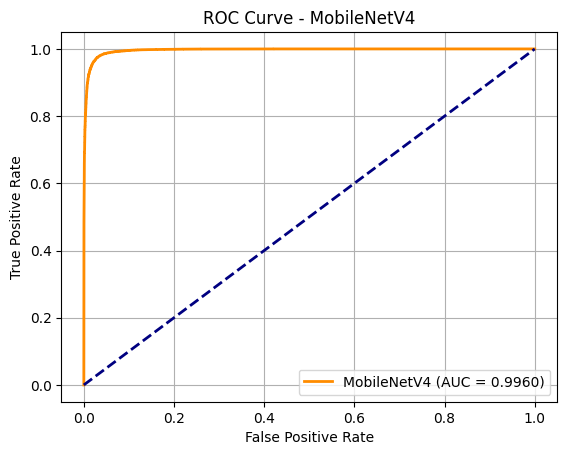

In [18]:
plot_roc_curve(model, test_loader, model_name="MobileNetV4")
